### Logistic Regression - Example and Practice Exercise

#### Exercise : Simple Logistic Regression

Problem Statement

* You are provided with a dataset (`student_exam.csv`) containing student features such as study hours and previous exam scores.

* The goal is to build a logistic regression model to predict whether a student will pass or fail an exam.

* You need to explore and visualize the data, then prepare it for modeling.

* The split the dataset into training and testing sets.

* Train a logistic regression model and evaluate it on test data.

* Visualize the decision boundary to interpret the model behavior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [3]:
df = pd.read_csv('customer_churn.csv')

In [5]:
df

,usage_hours,subscription_length,customer_churn
0,1,1,1
1,2,1,1
2,2,2,1
3,3,1,1
4,3,2,1
...,...,...,...
71,30,24,0
72,12,6,1
73,13,6,1
74,14,7,1


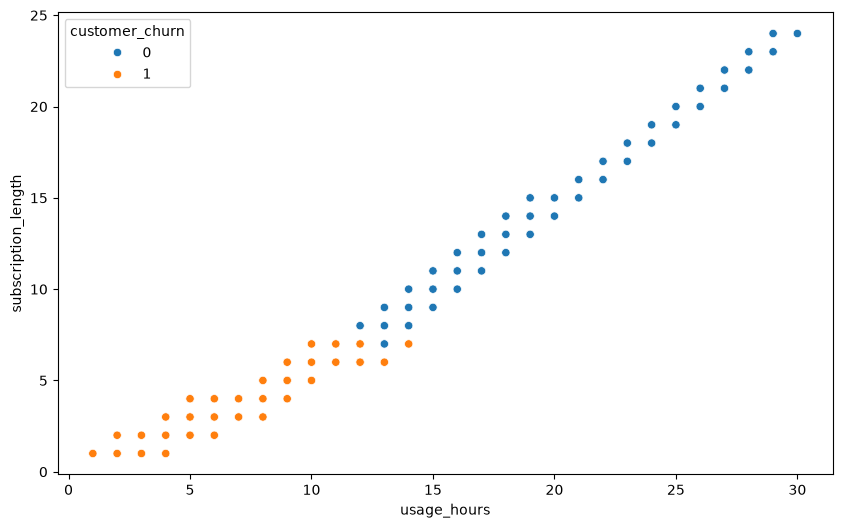

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='usage_hours', y='subscription_length', hue='customer_churn', data=df)
plt.show()

In [ ]:
X = df[['usage_hours', 'subscription_length']]
y  = df['customer_churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 60 samples
Testing set size: 16 samples


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='lbfgs')

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [20]:
y_pred = model.predict(X_test)
print(f"Predictions: {y_pred}")

Predictions: [1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0]


In [21]:
proba = model.predict_proba(X_test)
print(f"Predicted probabilities:\n{proba}")
proba_df = pd.DataFrame(proba, columns=['Probability of Not Churning', 'Probability of Churning']).round(2)

proba_df["Actual Churn"] = y_test.values
proba_df["Predicted Churn"] = y_pred
proba_df

Predicted probabilities:
[[2.61015251e-06 9.99997390e-01]
 [9.89077209e-01 1.09227908e-02]
 [1.33547833e-04 9.99866452e-01]
 [2.12543061e-07 9.99999787e-01]
 [9.99926780e-01 7.32203224e-05]
 [9.99995783e-01 4.21741100e-06]
 [1.00000000e+00 1.49292569e-12]
 [9.99999800e-01 2.00042190e-07]
 [9.99999410e-01 5.89567568e-07]
 [2.98087556e-01 7.01912444e-01]
 [1.00000000e+00 2.08700877e-13]
 [1.00000000e+00 7.00168419e-15]
 [2.80801677e-03 9.97191983e-01]
 [5.50261576e-05 9.99944974e-01]
 [9.99999999e-01 9.38179665e-10]
 [8.39107219e-01 1.60892781e-01]]


,Probability of Not Churning,Probability of Churning,Actual Churn,Predicted Churn
0,0.00,1.00,1,1
1,0.99,0.01,0,0
2,0.00,1.00,1,1
3,0.00,1.00,1,1
4,1.00,0.00,0,0
5,1.00,0.00,0,0
6,1.00,0.00,0,0
7,1.00,0.00,0,0
8,1.00,0.00,0,0
9,0.30,0.70,1,1


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[10,  0],
       [ 0,  6]])

Text(0.5, 36.38563368055554, 'Predicted')

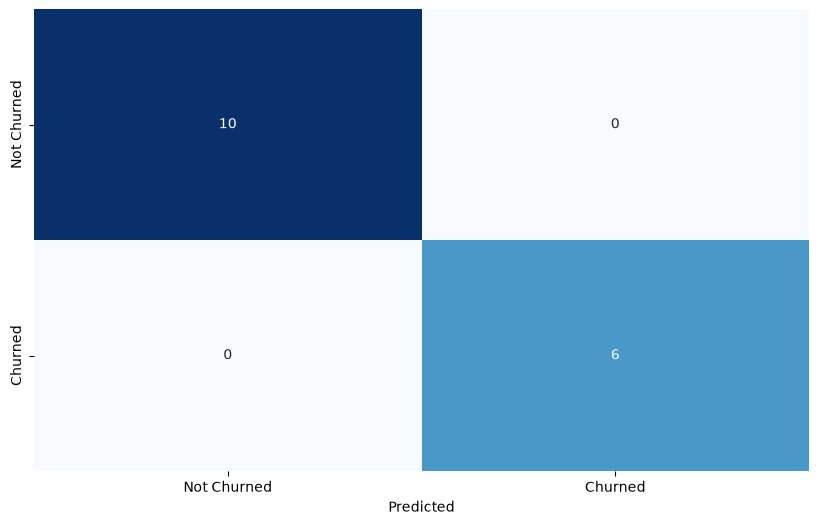

In [26]:
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'], cbar=False),
plt.xlabel('Predicted')

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         6

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16

